Install & Import Libraries

In [1]:
!pip install wordcloud
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import wordcloud
import warnings
warnings.filterwarnings('ignore')

Upload & Load the Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving training.1600000.processed.noemoticon.csv to training.1600000.processed.noemoticon.csv


In [3]:
# Load the dataset (no header in this file, so we name columns manually)
cols = ['target', 'ids', 'date', 'flag', 'user', 'text']

df = pd.read_csv('training.1600000.processed.noemoticon.csv',
                 encoding='latin-1',
                 names=cols)

print("Shape:", df.shape)
df.head()

Shape: (1600000, 6)


,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


 Quick Exploration

In [4]:
# Check data types and nulls
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   ids     1600000 non-null  int64 
 2   date    1600000 non-null  object
 3   flag    1600000 non-null  object
 4   user    1600000 non-null  object
 5   text    1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [5]:
# Check for missing values
df.isnull().sum()

,0
target,0
ids,0
date,0
flag,0
user,0
text,0


In [6]:
# Keep only what we need
df = df[['target', 'text']]

# Remap target: 0 = Negative, 4 = Positive → rename to 0 and 1
df['target'] = df['target'].replace(4, 1)

print("Sentiment value counts:")
print(df['target'].value_counts())

Sentiment value counts:
target
0    800000
1    800000
Name: count, dtype: int64


Visualize Class Distribution

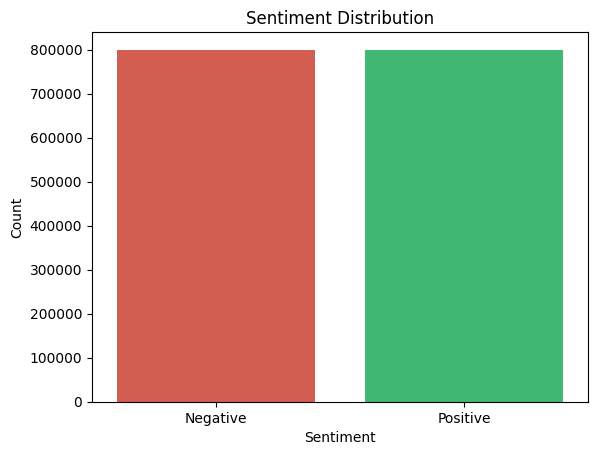

In [7]:
sns.countplot(x='target', data=df, palette=['#e74c3c', '#2ecc71'])
plt.title('Sentiment Distribution')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

Data Cleaning
Raw tweets are messy — they contain URLs, @mentions, hashtags, numbers, and punctuation that add noise. We'll strip all of that out.

Import Cleaning Libraries

In [8]:
import re
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Build the Cleaning Function

In [9]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    text = text.lower()                                  # Lowercase
    text = re.sub(r'http\S+|www\S+', '', text)          # Remove URLs
    text = re.sub(r'@\w+', '', text)                     # Remove @mentions
    text = re.sub(r'#(\w+)', r'\1', text)                # Remove # but keep word
    text = re.sub(r'[^a-z\s]', '', text)                 # Remove punctuation & numbers
    text = re.sub(r'\s+', ' ', text).strip()             # Remove extra spaces

    # Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]

    return ' '.join(tokens)

Apply Cleaning to the Dataset

In [10]:
# Sample for speed
df_sample = df.sample(n=200000, random_state=42).reset_index(drop=True)

# Apply cleaning (takes ~1-2 mins)
df_sample['clean_text'] = df_sample['text'].apply(clean_tweet)

print("✅ Cleaning done!")
df_sample[['text', 'clean_text']].head(5)

✅ Cleaning done!


,text,clean_text
0,@chrishasboobs AHHH I HOPE YOUR OK!!!,ahhh hope ok
1,"@misstoriblack cool , i have no tweet apps fo...",cool tweet apps razr
2,@TiannaChaos i know just family drama. its la...,know family drama lamehey next time u hang kim...
3,School email won't open and I have geography ...,school email wont open geography stuff revise ...
4,upper airways problem,upper airway problem


Remove Empty Rows After Cleaning

In [11]:
# Some tweets may become empty after cleaning
df_sample = df_sample[df_sample['clean_text'].str.strip() != '']
df_sample = df_sample.dropna(subset=['clean_text'])

print("Rows after cleaning:", len(df_sample))

Rows after cleaning: 199021


Tweet Length Distribution
Let's see if negative and positive tweets differ in length:

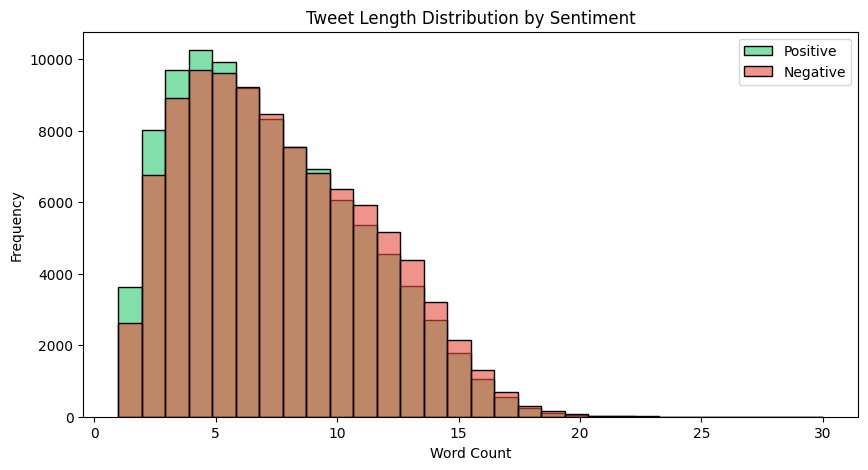

target
0    7.387163
1    6.988106
Name: tweet_length, dtype: float64


In [12]:
df_sample['tweet_length'] = df_sample['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(data=df_sample, x='tweet_length', hue='target',
             bins=30, palette=['#e74c3c', '#2ecc71'], alpha=0.6)
plt.title('Tweet Length Distribution by Sentiment')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend(labels=['Positive', 'Negative'])
plt.show()

print(df_sample.groupby('target')['tweet_length'].mean())

 Top 20 Most Common Words (Negative vs Positive)

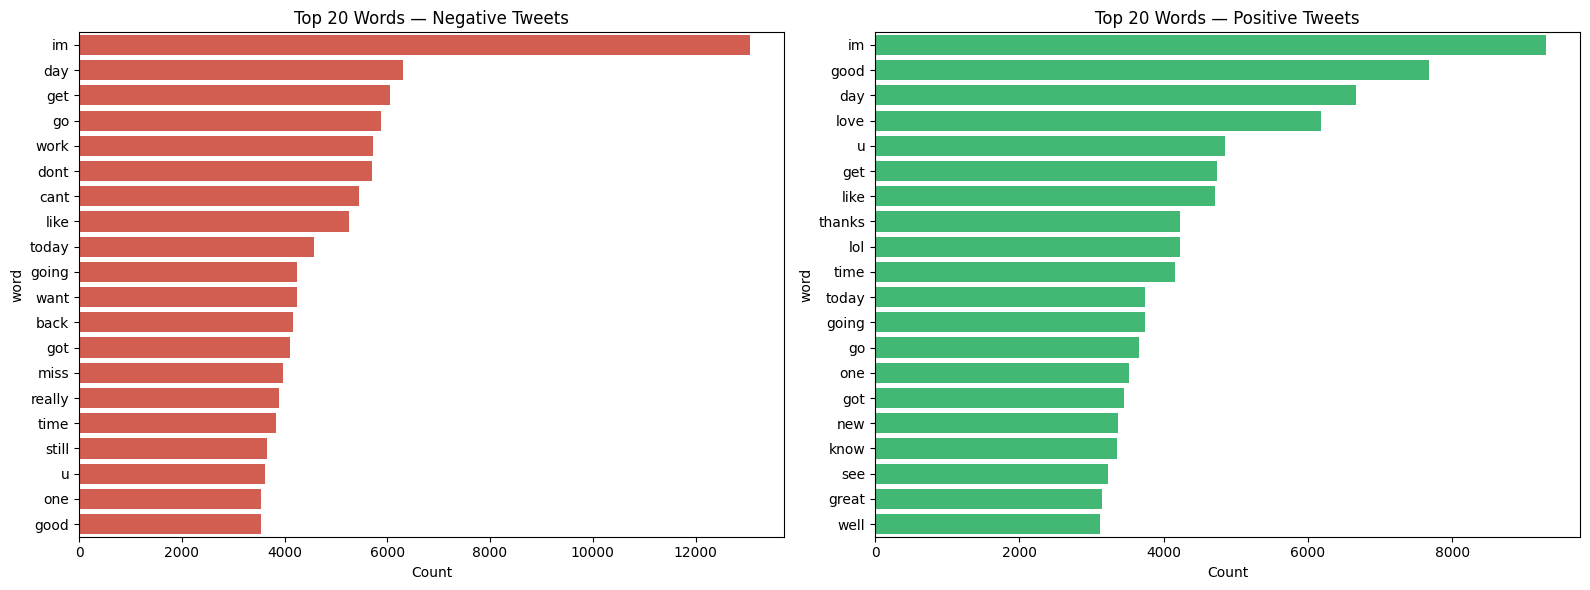

In [13]:
from collections import Counter

def get_top_words(df, sentiment, n=20):
    words = ' '.join(df[df['target'] == sentiment]['clean_text']).split()
    return Counter(words).most_common(n)

neg_words = get_top_words(df_sample, 0)
pos_words = get_top_words(df_sample, 1)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Negative
neg_df = pd.DataFrame(neg_words, columns=['word', 'count'])
sns.barplot(data=neg_df, x='count', y='word', ax=axes[0], color='#e74c3c')
axes[0].set_title('Top 20 Words — Negative Tweets')
axes[0].set_xlabel('Count')

# Positive
pos_df = pd.DataFrame(pos_words, columns=['word', 'count'])
sns.barplot(data=pos_df, x='count', y='word', ax=axes[1], color='#2ecc71')
axes[1].set_title('Top 20 Words — Positive Tweets')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

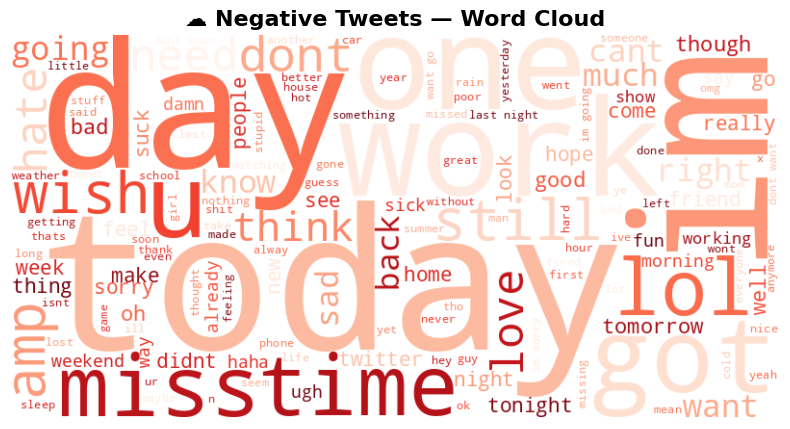

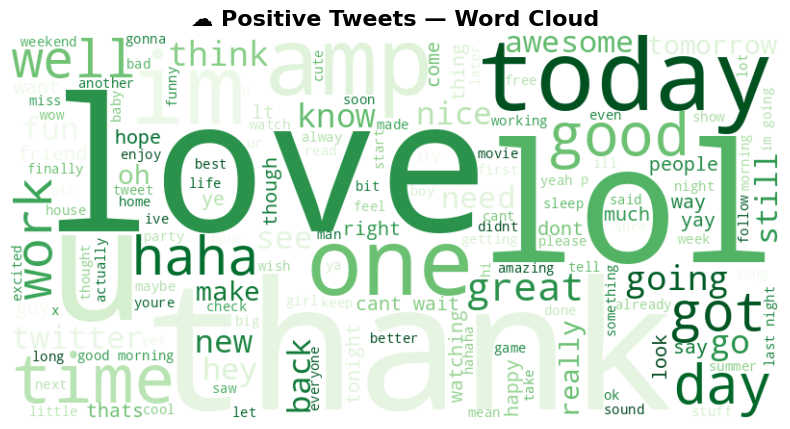

In [15]:
from wordcloud import WordCloud

def generate_wordcloud(df, sentiment, title, color):
    text = ' '.join(df[df['target'] == sentiment]['clean_text'])
    wc = WordCloud(width=800, height=400,
                   background_color='white',
                   colormap=color,
                   max_words=150).generate(text)
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.show()

generate_wordcloud(df_sample, 0, '☁️ Negative Tweets — Word Cloud', 'Reds')
generate_wordcloud(df_sample, 1, '☁️ Positive Tweets — Word Cloud', 'Greens')

Unique Words Per Sentiment

In [16]:
neg_vocab = set(' '.join(df_sample[df_sample['target']==0]['clean_text']).split())
pos_vocab = set(' '.join(df_sample[df_sample['target']==1]['clean_text']).split())

print(f"Unique words in Negative tweets: {len(neg_vocab):,}")
print(f"Unique words in Positive tweets: {len(pos_vocab):,}")
print(f"Words exclusive to Negative:     {len(neg_vocab - pos_vocab):,}")
print(f"Words exclusive to Positive:     {len(pos_vocab - neg_vocab):,}")

Unique words in Negative tweets: 57,121
Unique words in Positive tweets: 61,489
Words exclusive to Negative:     34,528
Words exclusive to Positive:     38,896


In [17]:
from sklearn.model_selection import train_test_split

X = df_sample['clean_text']
y = df_sample['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train):,}")
print(f"Testing samples:  {len(X_test):,}")

Training samples: 159,216
Testing samples:  39,805


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test):  {X_test_tfidf.shape}")

TF-IDF matrix shape (train): (159216, 50000)
TF-IDF matrix shape (test):  (39805, 50000)


In [19]:
from sklearn.linear_model import LogisticRegression
import time

print("Training model...")
start = time.time()

model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', n_jobs=-1)
model.fit(X_train_tfidf, y_train)

end = time.time()
print(f"✅ Model trained in {round(end - start, 2)} seconds")

Training model...
✅ Model trained in 4.51 seconds


In [20]:
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

y_pred = model.predict(X_test_tfidf)

# Accuracy
print(f"✅ Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

✅ Accuracy: 78.01%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.76      0.78     19878
    Positive       0.77      0.80      0.78     19927

    accuracy                           0.78     39805
   macro avg       0.78      0.78      0.78     39805
weighted avg       0.78      0.78      0.78     39805



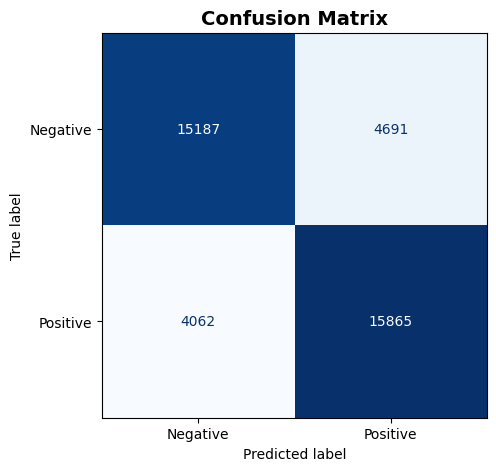

In [21]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Negative', 'Positive'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()

In [22]:
def predict_sentiment(text):
    cleaned = clean_tweet(text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]

    label = '🟢 Positive' if prediction == 1 else '🔴 Negative'
    confidence = max(probability) * 100

    print(f"Tweet:      {text}")
    print(f"Sentiment:  {label}")
    print(f"Confidence: {confidence:.2f}%")
    print("-" * 45)

# Try these out!
predict_sentiment("I love this product, it changed my life!")
predict_sentiment("This is the worst movie experience I've ever had.")
predict_sentiment("Just finished my data science project feeling great!")
predict_sentiment("So tired and frustrated with everything today.")

Tweet:      I love this product, it changed my life!
Sentiment:  🟢 Positive
Confidence: 82.65%
---------------------------------------------
Tweet:      This is the worst movie experience I've ever had.
Sentiment:  🔴 Negative
Confidence: 69.09%
---------------------------------------------
Tweet:      Just finished my data science project feeling great!
Sentiment:  🔴 Negative
Confidence: 70.98%
---------------------------------------------
Tweet:      So tired and frustrated with everything today.
Sentiment:  🔴 Negative
Confidence: 91.54%
---------------------------------------------


In [27]:
from google.colab import files

# This will overwrite the previous content of this cell.
# You may need to replace 'your_notebook_name.ipynb' with the actual name of your Colab notebook.
files.download('your_notebook_name.ipynb')

FileNotFoundError: Cannot find file: your_notebook_name.ipynb

In [24]:
from google.colab import files

files.download('sentiment_model.pkl')
files.download('tfidf_vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
import os
os.makedirs('plots', exist_ok=True)

# Tweet length distribution
df_sample['tweet_length'] = df_sample['clean_text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 5))
sns.histplot(data=df_sample, x='tweet_length', hue='target',
             bins=30, palette=['#e74c3c', '#2ecc71'], alpha=0.6)
plt.title('Tweet Length Distribution by Sentiment')
plt.savefig('plots/tweet_length.png', bbox_inches='tight')
plt.close()

# Word clouds
for sentiment, title, cmap, fname in [
    (0, 'Negative Tweets', 'Reds', 'wordcloud_negative'),
    (1, 'Positive Tweets', 'Greens', 'wordcloud_positive')
]:
    text = ' '.join(df_sample[df_sample['target'] == sentiment]['clean_text'])
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=150).generate(text)
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.savefig(f'plots/{fname}.png', bbox_inches='tight')
    plt.close()

print("✅ Plots saved!")

# Download plots folder as zip
import shutil
shutil.make_archive('plots', 'zip', 'plots')
files.download('plots.zip')

✅ Plots saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
files.download('plots.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>